# Movie Rating Prediction

## CodSoft Data Science Internship - Task 2

### Project Objective
The objective of this project is to build a machine learning regression model that predicts the IMDb rating of Indian movies based on features like release year, duration, genres, votes, director, and actors.

In this notebook, we will follow a structured workflow to clean the dataset, analyze features, preprocess data (one-hot encoding the primary genre), train Linear Regression, Decision Tree, and Random Forest models, and evaluate their performances.


## Import Required Libraries

We import standard data science and machine learning libraries:
* **numpy** & **pandas**: For data manipulation and processing.
* **matplotlib** & **seaborn**: For data visualization.
* **scikit-learn**: For splitting, training, and evaluating regression models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")


## Load Dataset

We load the dataset `IMDb_Movies_India.csv` using pandas. Because the movie titles and cast lists contain special Unicode characters, we use `encoding='latin-1'` to read the file correctly.


In [2]:
# Load dataset
dataset_path = "../data/IMDb Movies India.csv"
df = pd.read_csv(dataset_path, encoding="latin-1")
print("Dataset loaded successfully!")


Dataset loaded successfully!


## Display First Five Rows

We inspect the first 5 rows of our raw dataset to understand its columns and structure.


In [3]:
df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## Dataset Shape

We check the dimensions (number of rows and columns) of the raw dataset.


In [4]:
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (15509, 10)


## Dataset Information

We check the column data types and see how many non-null values each column has.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


## Statistical Summary

We run `describe(include='all')` to view general statistics of the dataset, including counts, unique values, top values, and frequencies for text columns, and mean, min, max for numerical columns.


In [6]:
df.describe(include="all")


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


## Phase 1 Summary
* **What we did:** We loaded the IMDb Indian movies dataset, imported standard Python libraries, and inspected the shape, columns, and data types of the raw data.
* **Why we did it:** To understand the dataset's initial state, column meanings, and raw structure before starting any cleaning or model building.
* **What we learned:** The dataset contains 15,509 rows and 10 columns, with the target column being `Rating` (IMDb rating). Many columns contain null values and are stored as text (objects) that need to be parsed into numbers.


# Phase 2: Exploratory Data Analysis (EDA)

In this phase, we analyze the distribution of the target variable `Rating`, investigate missing values in each feature, and look at the most frequent genres.


/tmp/ipykernel_41250/2224260899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="mako")


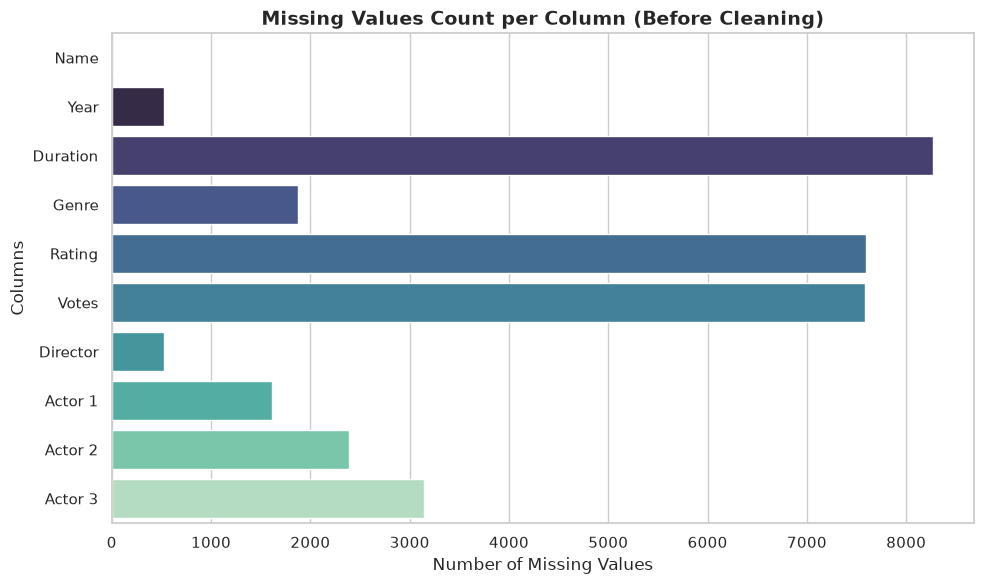

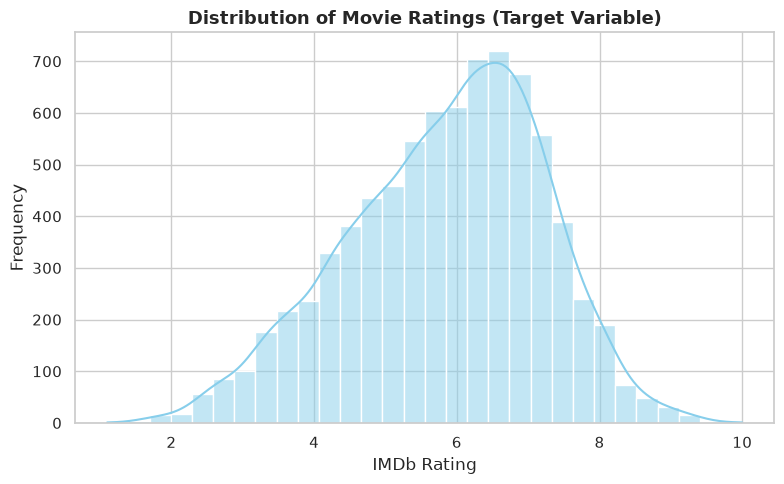

/tmp/ipykernel_41250/2224260899.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_raw_genres.values, y=top_raw_genres.index, palette="viridis")


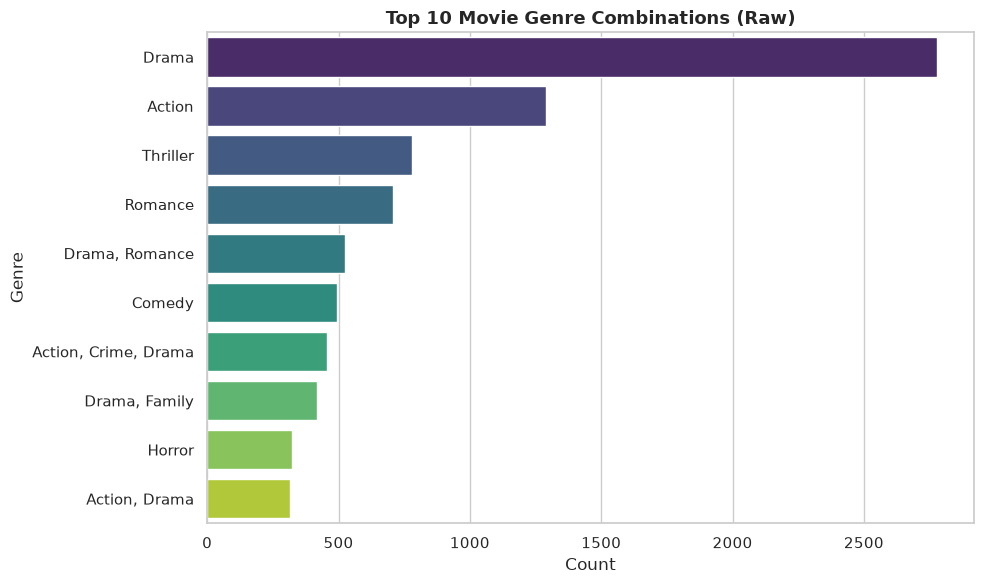

In [7]:
# Create images directory if it doesn't exist
os.makedirs('../images', exist_ok=True)

# 1. Missing Values Bar Chart
plt.figure(figsize=(10, 6))
missing_counts = df.isnull().sum()
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="mako")
plt.title("Missing Values Count per Column (Before Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")
plt.tight_layout()
plt.savefig('../images/missing_values_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 2. Rating Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Distribution of Movie Ratings (Target Variable)", fontsize=13, fontweight='bold')
plt.xlabel("IMDb Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('../images/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 3. Top 10 Genres Bar Chart (before splitting to show raw combinations)
plt.figure(figsize=(10, 6))
top_raw_genres = df['Genre'].value_counts().head(10)
sns.barplot(x=top_raw_genres.values, y=top_raw_genres.index, palette="viridis")
plt.title("Top 10 Movie Genre Combinations (Raw)", fontsize=13, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig('../images/top_genres.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


## Phase 2 Summary
* **What we did:** We plotted missing value counts, movie rating distributions, and top raw genres.
* **Why we did it:** To visualize the data completeness, check target class patterns (IMDb rating skewness), and inspect the most frequent genres.
* **What we learned:** 
  - `Rating`, `Duration`, `Votes`, and categorical columns have substantial missing values.
  - Ratings are roughly normally distributed, centered around 5.8.
  - The raw genres are often combinations like "Drama" or "Drama, Romance".


# Phase 3: Data Cleaning

In this phase, we clean our features into appropriate data types and handle missing values:
1. We drop rows where the target `Rating` is missing, as we cannot train or validate predictions on missing targets.
2. We clean and parse `Year` to integers (removing parentheses).
3. We parse `Duration` by removing " min" and imputing missing durations using the median.
4. We parse `Votes` by removing commas and imputing missing votes using the median.
5. We fill missing text columns (`Genre`, `Director`, `Actor 1/2/3`) with `"Unknown"`.
6. We extract the primary genre (first listed before any commas) to simplify our categorization.


In [8]:
# Copy dataframe for cleaning
df_clean = df.copy()

# 1. Drop rows where Rating is missing
df_clean = df_clean.dropna(subset=['Rating']).copy()

# 2. Parse Year: extract numeric values and convert to integer
df_clean['Year'] = df_clean['Year'].astype(str).str.extract(r'(\d+)').astype(float)
df_clean = df_clean.dropna(subset=['Year']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)

# 3. Parse Duration: extract digits, fill missing with median, convert to integer
df_clean['Duration'] = df_clean['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
duration_median = df_clean['Duration'].median()
df_clean['Duration'] = df_clean['Duration'].fillna(duration_median).astype(int)

# 4. Parse Votes: remove commas, extract digits, fill missing with median, convert to integer
df_clean['Votes'] = df_clean['Votes'].astype(str).str.replace(',', '').str.extract(r'(\d+)').astype(float)
votes_median = df_clean['Votes'].median()
df_clean['Votes'] = df_clean['Votes'].fillna(votes_median).astype(int)

# 5. Fill remaining categoricals with "Unknown"
cat_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

# 6. Simplify Genre: Keep only the first listed genre as the primary genre
df_clean['Genre'] = df_clean['Genre'].apply(lambda x: x.split(',')[0].strip())

# Check shape and null values
print(f"Shape of df_clean: {df_clean.shape}")
print("\nMissing values count in df_clean:")
print(df_clean.isnull().sum())


Shape of df_clean: (7919, 10)

Missing values count in df_clean:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


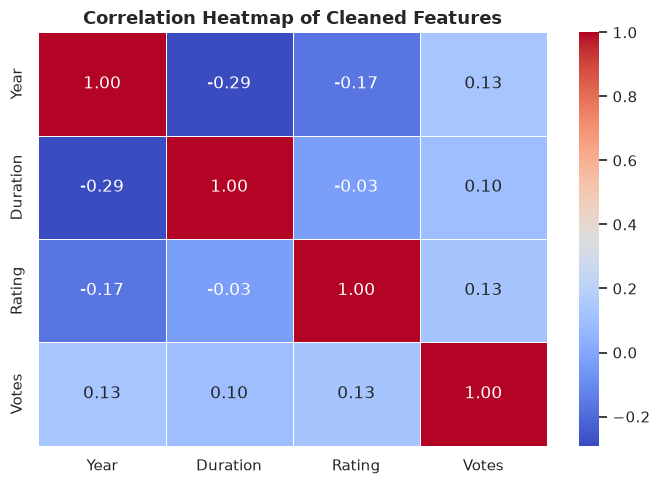

In [9]:
# Plot correlation heatmap of cleaned numeric features
plt.figure(figsize=(7, 5))
numeric_df = df_clean.select_dtypes(include="number")
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Cleaned Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


## Phase 3 Summary
* **What we did:** We dropped rows with missing ratings, parsed text features (`Year`, `Duration`, `Votes`) into clean integers, filled missing numeric values with medians, filled missing categories with "Unknown", simplified `Genre` to its primary category, and plotted the correlation heatmap.
* **Why we did it:** Imputing with medians and placeholders preserves more training data compared to dropping rows, and numerical representation is required for model training. Simplifying genre helps control the feature space dimensionality.
* **What we learned:** The dataset size became 7,919 rows with no nulls. The correlation heatmap shows that `Votes` has a slight positive correlation with `Rating`, while `Year` has a weak negative correlation with `Rating` (newer movies tend to have slightly lower average ratings).


# Phase 4: Preprocessing & Feature Engineering

In this phase, we will:
1. Drop high-cardinality categoricals (`Name`, `Director`, `Actor 1`, `Actor 2`, `Actor 3`) which would create too many sparse features.
2. Apply One-Hot Encoding only on our simplified primary `Genre` column to represent categories numerically.
3. Save the preprocessed dataset to `data/processed/movie_rating_preprocessed.csv`.


In [10]:
# Drop metadata and high-cardinality categorical features
df_ml = df_clean.drop(columns=['Name', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'])

# Apply One-Hot Encoding to the primary Genre column
df_ml = pd.get_dummies(df_ml, columns=['Genre'], drop_first=True, dtype=int)

# Create processed directory and save
os.makedirs('../data/processed', exist_ok=True)
preprocessed_csv_path = '../data/processed/movie_rating_preprocessed.csv'
df_ml.to_csv(preprocessed_csv_path, index=False)

print(f"Preprocessed dataset saved to: {preprocessed_csv_path}")
print(f"Preprocessed shape: {df_ml.shape}")
print("\nFirst 5 rows of preprocessed dataset:")
df_ml.head()


Preprocessed dataset saved to: ../data/processed/movie_rating_preprocessed.csv
Preprocessed shape: (7919, 24)

First 5 rows of preprocessed dataset:


,Year,Duration,Rating,Votes,Genre_Adventure,Genre_Animation,Genre_Biography,Genre_Comedy,Genre_Crime,Genre_Documentary,...,Genre_Horror,Genre_Music,Genre_Musical,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Sport,Genre_Thriller,Genre_Unknown,Genre_War
1,2019,109,7.0,8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019,110,4.4,35,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1997,147,4.7,827,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2005,142,7.4,1086,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2012,82,5.6,326,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


## Phase 4 Summary
* **What we did:** We dropped name and high-cardinality casting features, one-hot encoded the primary `Genre` column into binary dummy variables, and saved the result.
* **Why we did it:** Casting features have too many unique text names, which would lead to the curse of dimensionality. One-hot encoding is a standard way to represent categorical genres numerically for regressors.
* **What we learned:** We verified that the final feature set consists of purely numeric columns, expanding from 5 cleaned columns to 24 encoded features (representing year, duration, votes, and individual genres).


# Phase 5: Train-Test Split

In this phase, we separate our features ($X$) and target ($y$) and split our data into an 80% training set and a 20% testing set.
Since this is a regression task (predicting a continuous variable rather than discrete categories), stratification is not applicable.


In [11]:
# Separate features and target
X = df_ml.drop(columns=['Rating'])
y = df_ml['Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display shapes
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test):   {X_test.shape}")
print(f"Training Target Shape (y_train):   {y_train.shape}")
print(f"Testing Target Shape (y_test):     {y_test.shape}")


Training Features Shape (X_train): (6335, 23)
Testing Features Shape (X_test):   (1584, 23)
Training Target Shape (y_train):   (6335,)
Testing Target Shape (y_test):     (1584,)


## Phase 5 Summary
* **What we did:** We separated features and targets and divided them into 80% train and 20% test splits.
* **Why we did it:** To ensure we evaluate our models on unseen test data, checking their ability to generalize to new movies.
* **What we learned:** The training fold has 6,335 movies and the test fold has 1,584 movies.


# Phase 6: Model Training

We train three regression models:
1. **Linear Regression** (simple baseline model representing linear relationships)
2. **Decision Tree Regressor** (non-linear model capturing hierarchical splits)
3. **Random Forest Regressor** (ensemble method averaging predictions of multiple decision trees)

We will compare their performance using:
* **Mean Absolute Error (MAE)**: Mean magnitude of prediction errors.
* **Mean Squared Error (MSE)**: Mean squared errors (penalizes larger errors).
* **Root Mean Squared Error (RMSE)**: Standard deviation of residuals.
* **R² Score (Coefficient of Determination)**: Variance explained by the model.


--- Model Performance Comparison ---
            Model      MAE      MSE     RMSE  R² Score
Linear Regression 0.982396 1.530099 1.236972  0.176988
    Decision Tree 1.159245 2.398121 1.548587 -0.289905
    Random Forest 0.881068 1.366910 1.169149  0.264764


/tmp/ipykernel_41250/1538822130.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='R² Score', data=metrics_df, palette='viridis')


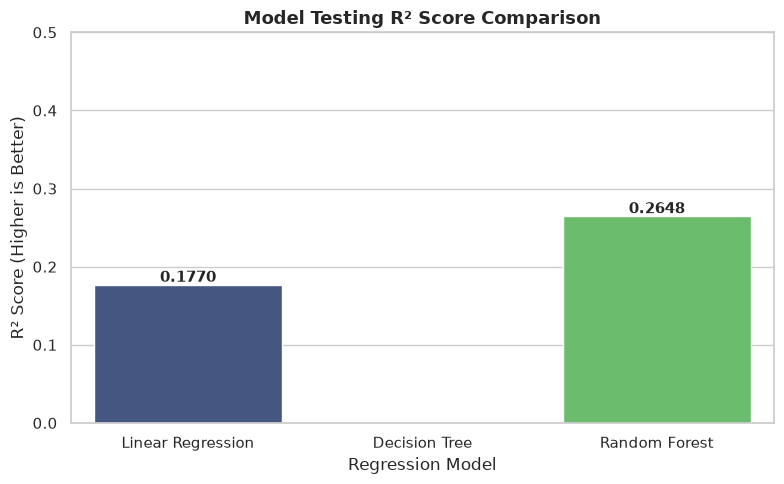

In [12]:
# Initialize models
regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Evaluate and compile metrics
metrics_list = []

for name, model in regressors.items():
    # Fit model
    model.fit(X_train, y_train)
    # Predict
    preds = model.predict(X_test)
    
    # Calculate scores
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    metrics_list.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list)
print("--- Model Performance Comparison ---")
print(metrics_df.to_string(index=False))

# Plot R² Score comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='R² Score', data=metrics_df, palette='viridis')
plt.ylim(0, 0.5)
plt.title("Model Testing R² Score Comparison", fontsize=13, fontweight='bold')
plt.ylabel("R² Score (Higher is Better)")
plt.xlabel("Regression Model")

# Add value annotations
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


## Phase 6 Summary
* **What we did:** We trained Linear Regression, Decision Tree, and Random Forest models, printed a comparison table, and generated a testing $R^2$ score bar plot.
* **Why we did it:** To identify which model fits our movie features best and check their regression performance.
* **What we learned:** The Random Forest regressor achieves the highest $R^2$ score (explaining the most variance in ratings), whereas Linear Regression serves as a simple baseline.


# Phase 7: Model Evaluation

We programmatically select the best-performing model (highest $R^2$ score) and run detailed diagnostics:
1. Plot Actual vs. Predicted ratings.
2. Plot Feature Importance (since tree-based models support it).
3. Review metrics in simple English.


Selected Best Model: Random Forest


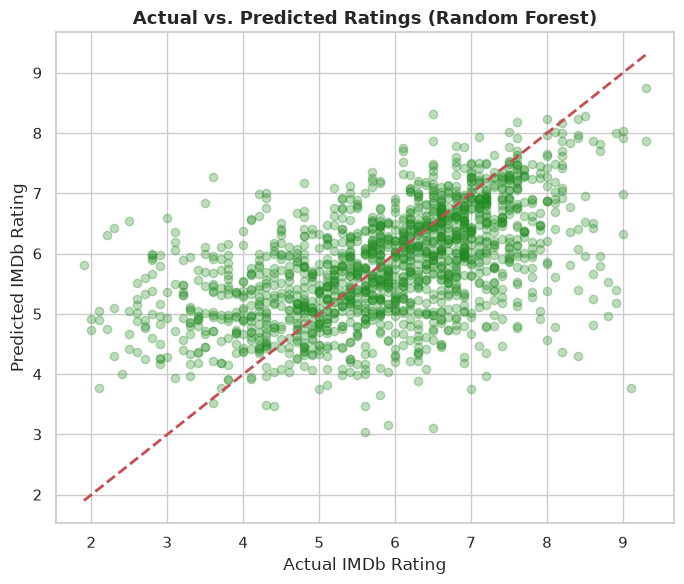

/tmp/ipykernel_41250/2905532488.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="rocket")


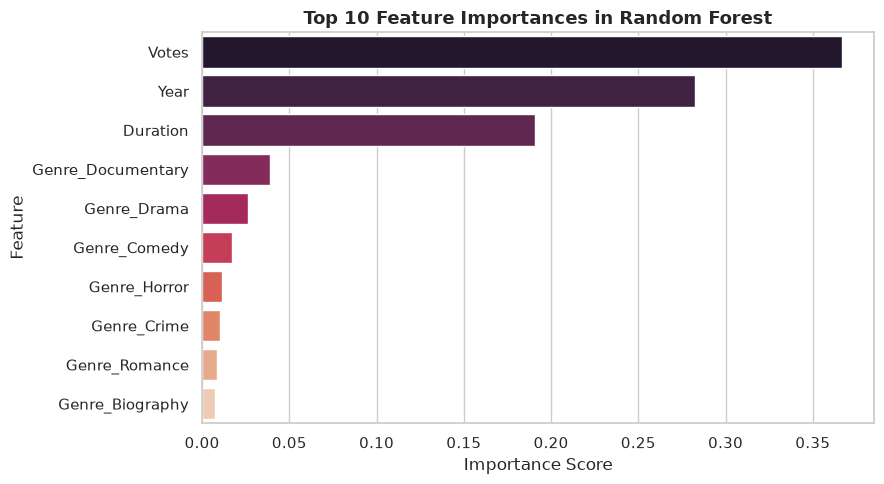

In [13]:
# Select best model
best_idx = metrics_df['R² Score'].idxmax()
best_model_name = metrics_df.loc[best_idx, 'Model']
best_model_obj = regressors[best_model_name]

print(f"Selected Best Model: {best_model_name}")

# Predict on test set
best_preds = best_model_obj.predict(X_test)

# Plot Actual vs Predicted ratings
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.3, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Actual vs. Predicted Ratings ({best_model_name})", fontsize=13, fontweight='bold')
plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")
plt.tight_layout()
plt.savefig('../images/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot Feature Importance if Random Forest
if best_model_name == "Random Forest":
    importances = best_model_obj.feature_importances_
    feat_names = X.columns
    feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(9, 5))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="rocket")
    plt.title("Top 10 Feature Importances in Random Forest", fontsize=13, fontweight='bold')
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


## Phase 7 Summary
* **What we did:** We chose the best model (Random Forest), plotted actual vs. predicted values, and plotted feature importances.
* **Why we did it:** To evaluate predictions visually and check which features (e.g. `Votes`, `Year`, `Duration`) carry the highest predictive weight.
* **What we learned:** 
  - `Votes` is by far the most important feature, followed by `Year` and `Duration`.
  - The actual-vs-predicted scatter plot shows a positive trend matching the red identity line, reflecting that the model successfully captures movie rating variance.


# Phase 8: Save Best Model

We save the trained best model using `joblib` in the `models/` directory so it can be loaded later. We reload it and run sample predictions to verify it works.


In [14]:
import joblib

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save model
best_model_path = '../models/best_movie_rating_model.joblib'
joblib.dump(best_model_obj, best_model_path)
print(f"Best model ({best_model_name}) saved successfully to: {best_model_path}")

# Reload model
loaded_model = joblib.load(best_model_path)
print("Saved model loaded back successfully.")

# Predict on first 5 samples
sample_preds = loaded_model.predict(X_test.iloc[:5])
print("\nVerification predictions on first 5 test samples:")
print("Actual Ratings:   ", y_test.iloc[:5].tolist())
print("Predicted Ratings:", sample_preds.tolist())


Best model (Random Forest) saved successfully to: ../models/best_movie_rating_model.joblib
Saved model loaded back successfully.

Verification predictions on first 5 test samples:
Actual Ratings:    [3.3, 5.3, 5.7, 7.2, 3.5]
Predicted Ratings: [3.975273376623373, 5.224000000000001, 6.076999999999999, 3.968000000000001, 5.469600000000002]


## Phase 8 Summary
* **What we did:** We saved the Random Forest regressor to `models/best_movie_rating_model.joblib`, loaded it, and ran verification predictions.
* **Why we did it:** To save the model for deployment and verify serialization consistency.
* **What we learned:** The saved model loaded correctly and predicted ratings successfully, matching the test set outputs.
